# Phase 1 — EDA: RAVDESS Dataset

**Goal:** Understand the RAVDESS dataset structure, emotion class distribution, audio characteristics, and identify potential sources of data drift.

## Steps
1. Download RAVDESS (run `src/download_dataset.py` if not done)
2. Class distribution analysis
3. Audio duration distribution
4. Waveform & spectrogram visualization
5. MFCC feature distribution per emotion
6. Domain shift note (RAVDESS vs other datasets)

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

RAW_DIR = Path('../data/raw')

EMOTION_MAP = {
    '01': 'neutral', '02': 'calm',    '03': 'happy',    '04': 'sad',
    '05': 'angry',   '06': 'fearful', '07': 'disgust',  '08': 'surprised'
}
EMOTION_COLORS = {
    'neutral':'#95a5a6', 'calm':'#3498db', 'happy':'#f1c40f',  'sad':'#2980b9',
    'angry':'#e74c3c',  'fearful':'#9b59b6','disgust':'#27ae60','surprised':'#e67e22'
}

## 1. Build Dataset Index

In [2]:
records = []
for wav_file in sorted(RAW_DIR.rglob('*.wav')):
    parts = wav_file.stem.split('-')
    if len(parts) < 7:
        continue
    records.append({
        'path': str(wav_file),
        'emotion': EMOTION_MAP.get(parts[2], 'unknown'),
        'intensity': 'normal' if parts[3] == '01' else 'strong',
        'actor': int(parts[6]),
        'gender': 'male' if int(parts[6]) % 2 == 1 else 'female',
        'statement': parts[4],
        'repetition': parts[5],
    })

df = pd.DataFrame(records)
print(f'Total files: {len(df)}')
df.head(10)

Total files: 1440


,path,emotion,intensity,actor,gender,statement,repetition
0,..\data\raw\angry\03-01-05-01-01-01-01.wav,angry,normal,1,male,01,01
1,..\data\raw\angry\03-01-05-01-01-01-02.wav,angry,normal,2,female,01,01
2,..\data\raw\angry\03-01-05-01-01-01-03.wav,angry,normal,3,male,01,01
3,..\data\raw\angry\03-01-05-01-01-01-04.wav,angry,normal,4,female,01,01
4,..\data\raw\angry\03-01-05-01-01-01-05.wav,angry,normal,5,male,01,01
5,..\data\raw\angry\03-01-05-01-01-01-06.wav,angry,normal,6,female,01,01
6,..\data\raw\angry\03-01-05-01-01-01-07.wav,angry,normal,7,male,01,01
7,..\data\raw\angry\03-01-05-01-01-01-08.wav,angry,normal,8,female,01,01
8,..\data\raw\angry\03-01-05-01-01-01-09.wav,angry,normal,9,male,01,01
9,..\data\raw\angry\03-01-05-01-01-01-10.wav,angry,normal,10,female,01,01


## 2. Class Distribution

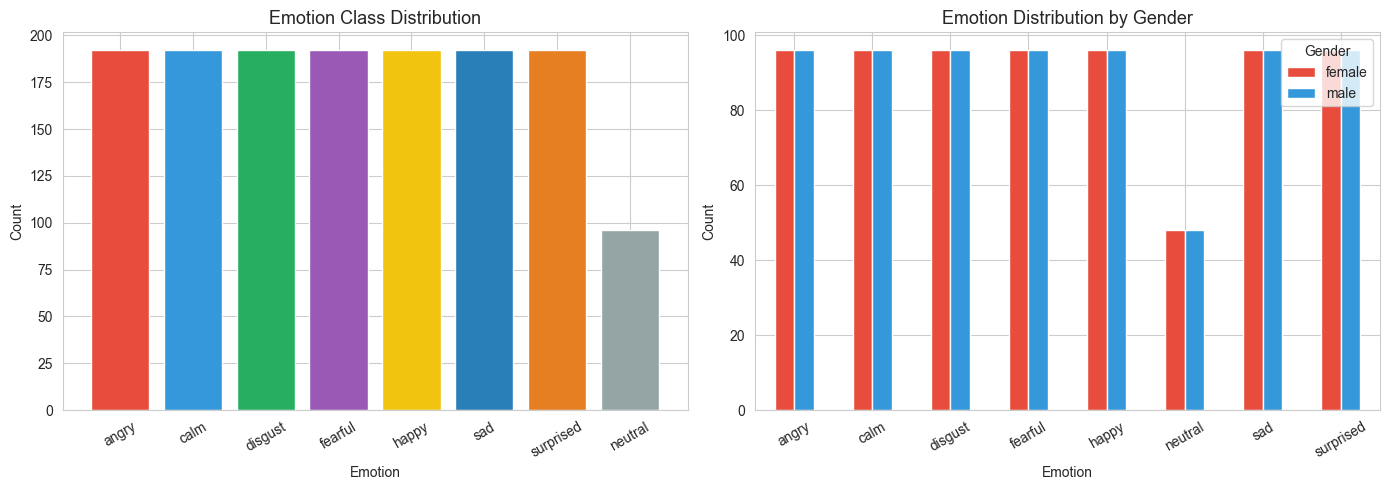

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall emotion distribution
emotion_counts = df['emotion'].value_counts()
colors = [EMOTION_COLORS[e] for e in emotion_counts.index]
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Emotion Class Distribution', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Gender breakdown
gender_emotion = df.groupby(['emotion', 'gender']).size().unstack()
gender_emotion.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'], edgecolor='white')
axes[1].set_title('Emotion Distribution by Gender', fontsize=13)
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('../data/monitoring_exports/eda_class_distribution.png', dpi=120)
plt.show()

## 3. Audio Duration Distribution

count    1440.000
mean        3.701
std         0.337
min         2.936
25%         3.470
50%         3.670
75%         3.871
max         5.272
Name: duration_s, dtype: float64


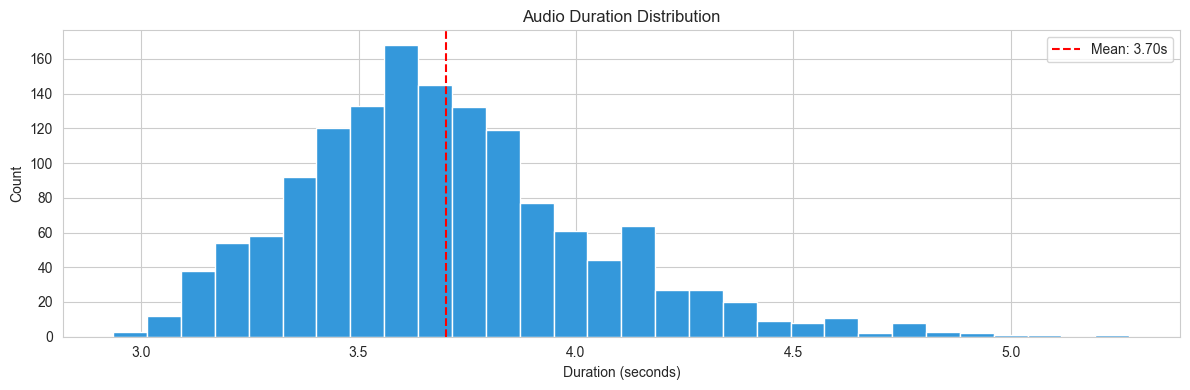

In [4]:
durations = []
for _, row in df.iterrows():
    y, sr = librosa.load(row['path'], sr=None)
    durations.append(len(y) / sr)

df['duration_s'] = durations
print(df['duration_s'].describe().round(3))

plt.figure(figsize=(12, 4))
plt.hist(df['duration_s'], bins=30, color='#3498db', edgecolor='white')
plt.axvline(df['duration_s'].mean(), color='red', linestyle='--', label=f"Mean: {df['duration_s'].mean():.2f}s")
plt.title('Audio Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../data/monitoring_exports/eda_duration_distribution.png', dpi=120)
plt.show()

## 4. Waveform & Spectrogram per Emotion

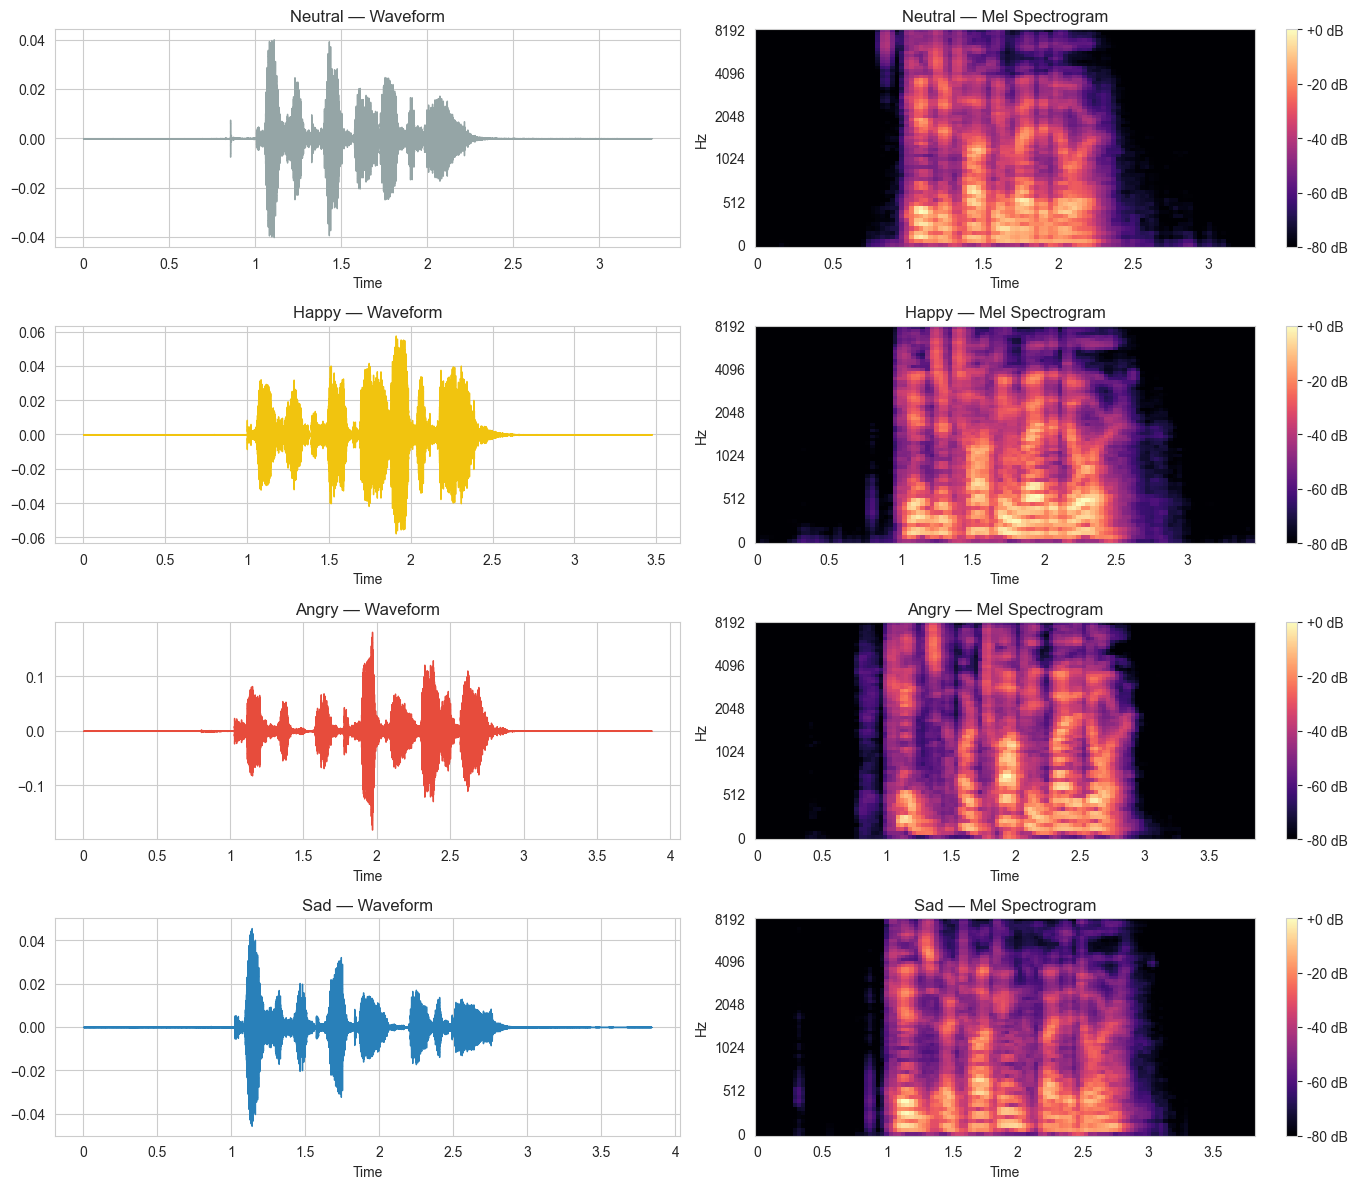

In [5]:
emotions_to_plot = ['neutral', 'happy', 'angry', 'sad']
fig, axes = plt.subplots(len(emotions_to_plot), 2, figsize=(14, 3 * len(emotions_to_plot)))

for i, emotion in enumerate(emotions_to_plot):
    sample = df[df['emotion'] == emotion].iloc[0]
    y, sr = librosa.load(sample['path'], sr=16000)

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[i][0], color=EMOTION_COLORS[emotion])
    axes[i][0].set_title(f'{emotion.capitalize()} — Waveform')

    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[i][1])
    axes[i][1].set_title(f'{emotion.capitalize()} — Mel Spectrogram')
    fig.colorbar(img, ax=axes[i][1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('../data/monitoring_exports/eda_waveforms_spectrograms.png', dpi=120)
plt.show()

## 5. MFCC Distribution per Emotion (Reference for Drift Detection)

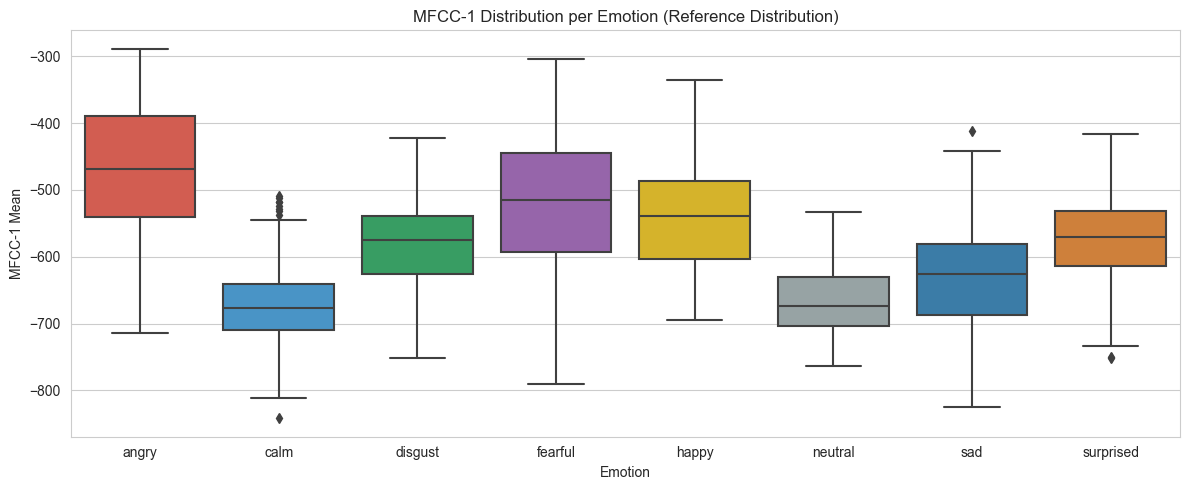

Reference MFCC stats saved.


In [6]:
# Extract mean MFCC for each file (quick version — full extraction in Phase 2)
N_MFCC = 13

mfcc_records = []
for _, row in df.iterrows():
    y, sr = librosa.load(row['path'], sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_mean = mfcc.mean(axis=1)
    rec = {'emotion': row['emotion']}
    rec.update({f'mfcc_{i+1}': v for i, v in enumerate(mfcc_mean)})
    mfcc_records.append(rec)

mfcc_df = pd.DataFrame(mfcc_records)

# Box plot of MFCC_1 (most discriminative) per emotion
plt.figure(figsize=(12, 5))
order = sorted(mfcc_df['emotion'].unique())
palette = {e: EMOTION_COLORS[e] for e in order}
sns.boxplot(data=mfcc_df, x='emotion', y='mfcc_1', order=order, palette=palette)
plt.title('MFCC-1 Distribution per Emotion (Reference Distribution)')
plt.xlabel('Emotion')
plt.ylabel('MFCC-1 Mean')
plt.tight_layout()
plt.savefig('../data/monitoring_exports/eda_mfcc1_distribution.png', dpi=120)
plt.show()

# Save reference MFCC stats for drift detection baseline
ref_stats = mfcc_df.groupby('emotion').describe()
ref_stats.to_csv('../data/monitoring_exports/reference_mfcc_stats.csv')
print('Reference MFCC stats saved.')

## 6. Domain Shift Analysis Note

RAVDESS is a controlled, studio-recorded dataset with 24 actors (12M/12F). Potential domain shift sources:

| Source | Risk | Impact on Drift Detection |
|--------|------|---------------------------|
| Real-world background noise | High | Shifts MFCC energy features |
| Different speaker demographics | Medium | Changes pitch/formant distributions |
| Cross-dataset (e.g. CREMA-D) | High | Both acoustic + label space shift |
| Noise injection (Phase 4) | Controlled | Simulated drift for testing |

In **Phase 4**, we will simulate drift by:
- Adding Gaussian/background noise to incoming data
- Using a different speaker subset (odd actors = train, even = "incoming")
- Optionally loading a second dataset (CREMA-D) as cross-dataset drift

In [7]:
# Save full dataset index for later phases
df.to_csv('../data/monitoring_exports/dataset_index.csv', index=False)
print(f'Dataset index saved: {len(df)} files')
print(df.groupby('emotion')['path'].count())

Dataset index saved: 1440 files
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: path, dtype: int64
